EXERCÍCIO 3 — BALANCEAMENTO DE CARGA
Melhor alocação: [2 1 2 2 0 3 3 0 0 2 0 3 3 3 1 2 1 2 1 1]
Makespan final: 137.00 segundos

Carga por servidor:
Servidor 0: 134.00 segundos
Servidor 1: 136.00 segundos
Servidor 2: 134.00 segundos
Servidor 3: 137.00 segundos

DISTRIBUIÇÃO DAS TAREFAS:

Servidor 0:
Tarefas: [4, 7, 8, 10]
Tempos: [15, 45, 60, 14]

Servidor 1:
Tarefas: [1, 14, 16, 18, 19]
Tempos: [35, 25, 42, 5, 29]

Servidor 2:
Tarefas: [0, 2, 3, 9, 15, 17]
Tempos: [12, 40, 8, 31, 33, 10]

Servidor 3:
Tarefas: [5, 6, 11, 12, 13]
Tempos: [22, 19, 28, 50, 18]


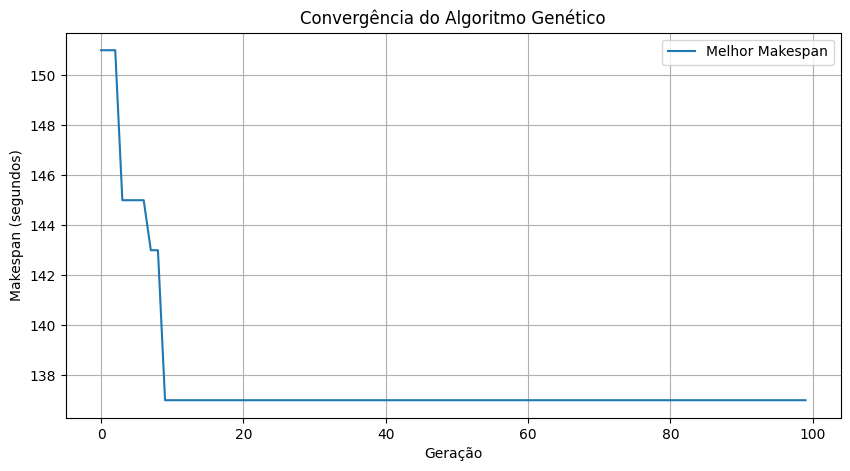

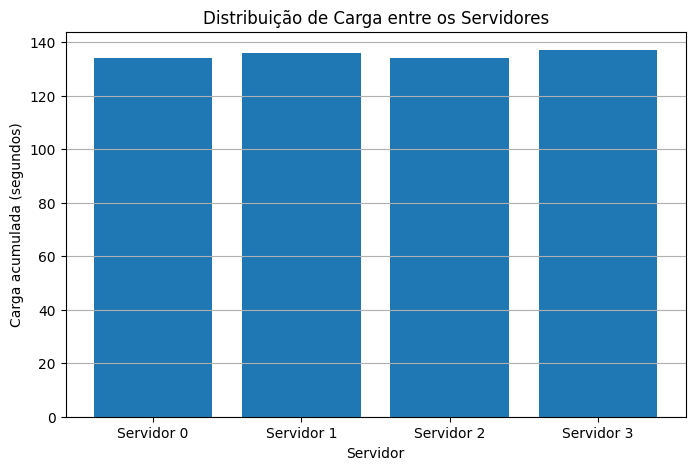

In [1]:
# ============================================================
# EXERCÍCIO 3 — BALANCEAMENTO DE CARGA EM SERVIDORES
# ============================================================

import numpy as np
import random
import matplotlib.pyplot as plt


# ============================================================
# 1. CONFIGURAÇÕES
# ============================================================

np.random.seed(2026)
random.seed(2026)

# Tempos de processamento das 20 tarefas (segundos)
T = [
    12, 35, 40, 8, 15,
    22, 19, 45, 60, 31,
    14, 28, 50, 18, 25,
    33, 42, 10, 5, 29
]

NUM_TAREFAS = len(T)

NUM_SERVIDORES = 4

TAMANHO_POPULACAO = 50

NUM_GERACOES = 100

TAXA_MUTACAO = 0.10


# ============================================================
# 2. CRIAÇÃO DE INDIVÍDUO
# ============================================================
# Cada posição representa uma tarefa.
# O valor representa o servidor:
#
# 0 = servidor 0
# 1 = servidor 1
# 2 = servidor 2
# 3 = servidor 3
#
# Exemplo:
# [0, 1, 2, 3, ...]
#
# significa que a tarefa 0 vai para o servidor 0,
# a tarefa 1 vai para o servidor 1, etc.

def criar_individuo():

    return np.random.randint(
        0,
        NUM_SERVIDORES,
        NUM_TAREFAS
    )


# ============================================================
# 3. CRIAÇÃO DA POPULAÇÃO
# ============================================================

def criar_populacao():

    return [
        criar_individuo()
        for _ in range(TAMANHO_POPULACAO)
    ]


# ============================================================
# 4. CÁLCULO DAS CARGAS
# ============================================================

def calcular_cargas(individuo):

    cargas = np.zeros(
        NUM_SERVIDORES
    )

    for tarefa in range(NUM_TAREFAS):

        servidor = individuo[tarefa]

        cargas[servidor] += T[tarefa]

    return cargas


# ============================================================
# 5. CÁLCULO DO MAKESPAN
# ============================================================

def calcular_makespan(individuo):

    cargas = calcular_cargas(
        individuo
    )

    return np.max(cargas)


# ============================================================
# 6. SELEÇÃO POR TORNEIO
# ============================================================

def selecao_torneio(
    populacao,
    tamanho_torneio=3
):

    participantes = random.sample(
        populacao,
        tamanho_torneio
    )

    vencedor = min(
        participantes,
        key=calcular_makespan
    )

    return vencedor.copy()


# ============================================================
# 7. CROSSOVER
# ============================================================

def crossover(pai1, pai2):

    ponto = random.randint(
        1,
        NUM_TAREFAS - 1
    )

    filho = np.concatenate(
        (
            pai1[:ponto],
            pai2[ponto:]
        )
    )

    return filho


# ============================================================
# 8. MUTAÇÃO
# ============================================================

def mutacao(individuo):

    individuo = individuo.copy()

    for i in range(NUM_TAREFAS):

        if random.random() < TAXA_MUTACAO:

            individuo[i] = random.randint(
                0,
                NUM_SERVIDORES - 1
            )

    return individuo


# ============================================================
# 9. EXECUÇÃO DO ALGORITMO GENÉTICO
# ============================================================

populacao = criar_populacao()

melhor_individuo = None

melhor_makespan = float("inf")

historico = []


for geracao in range(NUM_GERACOES):

    # Avalia todos os indivíduos
    makespans = [
        calcular_makespan(ind)
        for ind in populacao
    ]

    # Melhor indivíduo da geração
    indice_melhor = np.argmin(
        makespans
    )

    melhor_geracao = populacao[
        indice_melhor
    ].copy()

    makespan_geracao = makespans[
        indice_melhor
    ]


    # Atualiza o melhor global
    if makespan_geracao < melhor_makespan:

        melhor_makespan = (
            makespan_geracao
        )

        melhor_individuo = (
            melhor_geracao.copy()
        )


    historico.append(
        melhor_makespan
    )


    # Elitismo
    nova_populacao = [
        melhor_individuo.copy()
    ]


    # Reprodução
    while len(nova_populacao) < TAMANHO_POPULACAO:

        pai1 = selecao_torneio(
            populacao
        )

        pai2 = selecao_torneio(
            populacao
        )

        filho = crossover(
            pai1,
            pai2
        )

        filho = mutacao(
            filho
        )

        nova_populacao.append(
            filho
        )


    populacao = nova_populacao


# ============================================================
# 10. RESULTADO FINAL
# ============================================================

cargas_finais = calcular_cargas(
    melhor_individuo
)

makespan_final = calcular_makespan(
    melhor_individuo
)


print("=" * 60)
print("EXERCÍCIO 3 — BALANCEAMENTO DE CARGA")
print("=" * 60)

print(
    f"Melhor alocação: "
    f"{melhor_individuo}"
)

print(
    f"Makespan final: "
    f"{makespan_final:.2f} segundos"
)

print("\nCarga por servidor:")

for servidor in range(
    NUM_SERVIDORES
):

    print(
        f"Servidor {servidor}: "
        f"{cargas_finais[servidor]:.2f} segundos"
    )

print("=" * 60)


# ============================================================
# 11. DETALHAMENTO DAS TAREFAS
# ============================================================

print("\nDISTRIBUIÇÃO DAS TAREFAS:")

for servidor in range(
    NUM_SERVIDORES
):

    tarefas = [
        i
        for i in range(NUM_TAREFAS)
        if melhor_individuo[i] == servidor
    ]

    print(
        f"\nServidor {servidor}:"
    )

    print(
        f"Tarefas: {tarefas}"
    )

    print(
        "Tempos: "
        f"{[T[i] for i in tarefas]}"
    )


# ============================================================
# 12. GRÁFICO DE CONVERGÊNCIA
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    historico,
    label="Melhor Makespan"
)

plt.xlabel(
    "Geração"
)

plt.ylabel(
    "Makespan (segundos)"
)

plt.title(
    "Convergência do Algoritmo Genético"
)

plt.grid(True)

plt.legend()

plt.show()


# ============================================================
# 13. GRÁFICO DA CARGA DOS SERVIDORES
# ============================================================

plt.figure(
    figsize=(8, 5)
)

servidores = [
    f"Servidor {i}"
    for i in range(NUM_SERVIDORES)
]

plt.bar(
    servidores,
    cargas_finais
)

plt.xlabel(
    "Servidor"
)

plt.ylabel(
    "Carga acumulada (segundos)"
)

plt.title(
    "Distribuição de Carga entre os Servidores"
)

plt.grid(
    axis="y"
)

plt.show()